In [2]:
# Zelle 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import pymongo
import os
from tensorflow.keras.utils import Sequence, to_categorical
import gc  # Garbage Collector


2024-11-14 12:50:44.070163: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-14 12:50:44.094512: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-14 12:50:44.412941: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
# Zelle 2: Datenbankverbindung und Datenladung
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    # Daten laden
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    # In DataFrames konvertieren
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    # Merge der DataFrames
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                        left_on='fingerprintId', 
                        right_on='_id', 
                        suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Daten laden
merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")

Gesamtdatensatz enthält 2000000 Einträge.


In [4]:
# Benutzer-IDs extrahieren
user_ids = merged_df['username'].unique()

# DataFrames für jeden Benutzer erstellen
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Beispielhafte Anzeige der ersten 5 Zeilen für jeden Benutzer
for user_id, df in user_dfs.items():
    print(f"Erste 5 Zeilen für Benutzer {user_id}:")
    display(df.head())

Erste 5 Zeilen für Benutzer benutzername_1:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
0,66e326e9fab6918841db55df,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.906,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
1,66e326e9fab6918841db55db,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.847,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
2,66e326e9fab6918841db55d6,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.772,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
3,66e326e9fab6918841db55e3,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.981,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
4,66e326eafab6918841db55eb,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:46.118,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0


Erste 5 Zeilen für Benutzer benutzername_3:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
100000,6703f8369717b7a0d179d6e3,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.318,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100001,6703f8369717b7a0d179d6e7,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.339,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100002,6703f8369717b7a0d179d6eb,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.359,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100003,6703f8369717b7a0d179d6ef,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.379,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100004,6703f8369717b7a0d179d6f7,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.412,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0


Erste 5 Zeilen für Benutzer benutzername_4:


...

,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1700000,6707bdebffc8085dd61d7c85,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.742,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700001,6707bdebffc8085dd61d7c8d,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.756,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700002,6707bdebffc8085dd61d7c99,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.773,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700003,6707bdebffc8085dd61d7ca1,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.787,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700004,6707bdebffc8085dd61d7ca9,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.803,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0


Erste 5 Zeilen für Benutzer benutzername_21:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1800000,6707c487ffc8085dd625a040,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.494,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800001,6707c487ffc8085dd625a044,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.506,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800002,6707c487ffc8085dd625a048,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.517,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800003,6707c487ffc8085dd625a04c,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.528,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800004,6707c487ffc8085dd625a050,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.539,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0


Erste 5 Zeilen für Benutzer benutzername_22:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1900000,6707cabdffc8085dd62a72c5,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.957,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900001,6707cabdffc8085dd62a72d1,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.970,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900002,6707cabdffc8085dd62a72ca,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.964,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900003,6707cabdffc8085dd62a72dd,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.981,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900004,6707cabdffc8085dd62a72e1,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.985,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0


In [5]:
# Funktion zur Verarbeitung der Bilder in NumPy-Arrays (X für Bilder, y für Labels)
def process_image(base64_str, target_size=(64, 64)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data))
        image = image.convert('RGB')
        image = image.resize(target_size)
        return np.array(image) / 255.0  # Normalisierung auf Werte zwischen 0 und 1
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None
    
def load_images(df, target_size=(64, 64)):
    X = []
    y = []
    for _, row in df.iterrows():
        img = process_image(row['sampleData'], target_size)
        if img is not None:
            X.append(img)
            y.append(1)  # Da alle Einträge zu 'benutzername_1' gehören (Label 1)
    return np.array(X), np.array(y)

In [6]:

# Beispiel für Benutzer 1
example_user_id = 'benutzername_1'
user_df = user_dfs[example_user_id]

In [7]:

# Aufteilung in Train/Val/Test-Sets (70% Train, 20% Val, 10% Test)
train_indices, test_indices = train_test_split(np.arange(len(user_df)), test_size=0.1, random_state=42)
train_indices, val_indices = train_test_split(train_indices, test_size=0.2222, random_state=42)  # 0.2222 * 0.9 ≈ 0.2

train_df = user_df.iloc[train_indices]
val_df = user_df.iloc[val_indices]
test_df = user_df.iloc[test_indices]

# Anzahl der Daten in den Sets ausgeben
print(f"Anzahl der Daten im Trainings-Set: {len(train_df)}")
print(f"Anzahl der Daten im Validierungs-Set: {len(val_df)}")
print(f"Anzahl der Daten im Test-Set: {len(test_df)}")


X_train, y_train = load_images(train_df)
X_val, y_val = load_images(val_df)
X_test, y_test = load_images(test_df)

# Normalisiere die Bilddaten
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# One-Hot-Encoding der Labels
y_train = to_categorical(y_train, num_classes=2)
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

Anzahl der Daten im Trainings-Set: 70002
Anzahl der Daten im Validierungs-Set: 19998
Anzahl der Daten im Test-Set: 10000


In [8]:
# CNN-Modell erstellen
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



2024-11-14 12:51:25.680856: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-14 12:51:25.681035: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-14 12:51:25.697412: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [9]:
# Modell trainieren
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

2024-11-14 12:51:38.161309: W tensorflow/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.20GiB (rounded to 3440738304)requested by op _EagerConst
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2024-11-14 12:51:38.161406: I tensorflow/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2024-11-14 12:51:38.161427: I tensorflow/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 19, Chunks in use: 19. 4.8KiB allocated for chunks. 4.8KiB in use in bin. 464B client-requested in use in bin.
2024-11-14 12:51:38.161442: I tensorflow/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 2, Chunks in use: 2. 1.0KiB allocated for chunks. 1.0KiB in use in bin. 1.0KiB client-requested in use in bin.
2024-11-14 12:51:38.161455: I tensorflow/tsl/framework/bfc_

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [ ]:
# Modell speichern mit spezifischem Namen und im korrekten Ordner
notebook_name = "CNN.ipynb"  # Ersetzen Sie dies durch den tatsächlichen Namen des Notebooks
notebook_base_name = os.path.splitext(notebook_name)[0]
specific_model_dir = os.path.join("Modelle", notebook_base_name)
os.makedirs(specific_model_dir, exist_ok=True)
specific_model_path = os.path.join(specific_model_dir, f"{notebook_base_name}_cnn_model.h5")
model.save(specific_model_path)
print(f"Modell spezifisch gespeichert unter: {specific_model_path}")

NameError: name 'os' is not defined

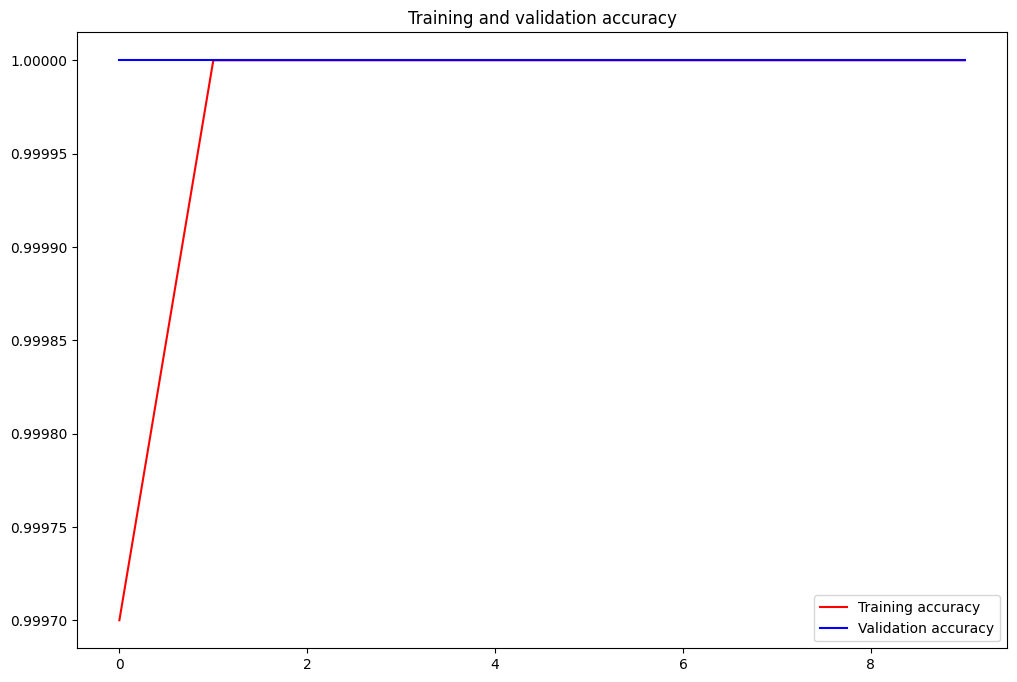

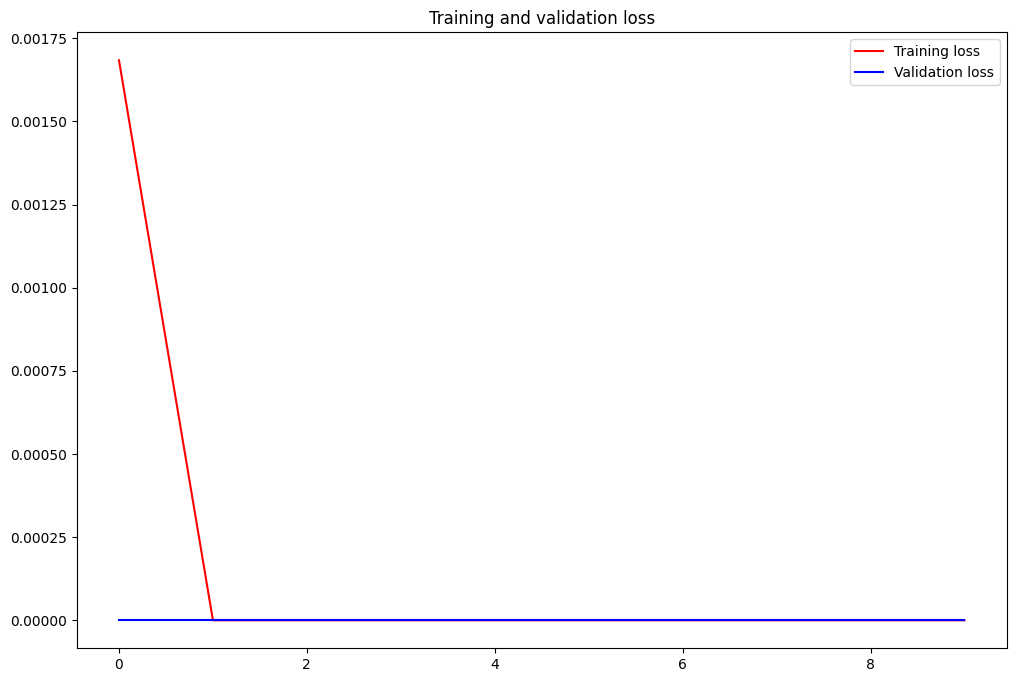

313/313 [==============================] - 3s 8ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Test accuracy: 1.0


In [34]:
# Trainings- und Validierungsgenauigkeit und -verlust plotten
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(12, 8))
    plt.plot(epochs, acc, 'r', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure(figsize=(12, 8))
    plt.plot(epochs, loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

plot_training_history(history)

# Modell evaluieren
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

32/32 [==============================] - 0s 3ms/step


,User,True Label,Predicted Probability,Predicted Label
0,benutzername_1,1,1.0,1
1,benutzername_1,1,1.0,1
2,benutzername_1,1,1.0,1
3,benutzername_1,1,1.0,1
4,benutzername_1,1,1.0,1
...,...,...,...,...
995,benutzername_22,0,1.0,1
996,benutzername_22,0,1.0,1
997,benutzername_22,0,1.0,1
998,benutzername_22,0,1.0,1


,User,True Label,Predicted Probability,Predicted Label
0,benutzername_1,1,1.0,1
671,benutzername_16,0,1.0,1
658,benutzername_16,0,1.0,1
659,benutzername_16,0,1.0,1
660,benutzername_16,0,1.0,1
...,...,...,...,...
338,benutzername_8,0,1.0,1
339,benutzername_8,0,1.0,1
340,benutzername_8,0,1.0,1
341,benutzername_8,0,1.0,1


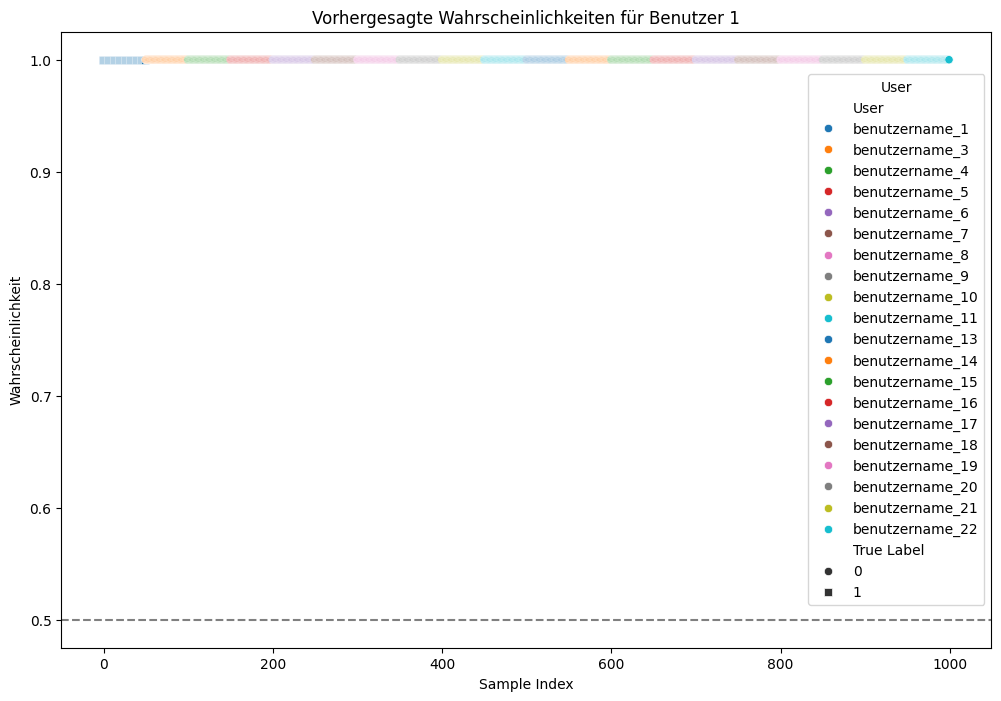

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Zufällige Samples von verschiedenen Benutzern auswählen
random_samples = []
random_labels = []
sample_users = []

for user_id in user_ids:
    user_df = user_dfs[user_id]
    samples = user_df.sample(n=50, random_state=42)  # 50 Samples pro Benutzer
    random_samples.extend(samples['sampleData'].tolist())
    sample_users.extend([user_id] * 50)
    if user_id == example_user_id:
        random_labels.extend([1] * 50)  # Label 1 für Benutzer 1
    else:
        random_labels.extend([0] * 50)  # Label 0 für andere Benutzer

# Bilddaten verarbeiten
X_random = np.array([process_image(sample) for sample in random_samples])
X_random = X_random / 255.0  # Normalisierung

# Vorhersagen mit dem Modell durchführen
y_pred = model.predict(X_random)
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_prob = y_pred[:, 1]  # Wahrscheinlichkeiten für Klasse 1 (Benutzer 1)

# Wahrscheinlichkeiten und Labels in einem DataFrame speichern
results_df = pd.DataFrame({
    'User': sample_users,
    'True Label': random_labels,
    'Predicted Probability': y_pred_prob,
    'Predicted Label': y_pred_classes
})

# Tabelle anzeigen
display(results_df)

# Sortieren nach vorhergesagter Wahrscheinlichkeit
sorted_results_df = results_df.sort_values(by='Predicted Probability', ascending=False)
display(sorted_results_df)

# Graphen erstellen
plt.figure(figsize=(12, 8))
sns.scatterplot(data=results_df, x=range(len(results_df)), y='Predicted Probability', hue='User', style='True Label', palette='tab10', markers=['o', 's'])
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('Vorhergesagte Wahrscheinlichkeiten für Benutzer 1')
plt.xlabel('Sample Index')
plt.ylabel('Wahrscheinlichkeit')
plt.legend(title='User')
plt.show()

32/32 [==============================] - 0s 3ms/step


,User,True Label,Predicted Probability,Predicted Label
0,benutzername_1,1,1.0,1
1,benutzername_1,1,1.0,1
2,benutzername_1,1,1.0,1
3,benutzername_1,1,1.0,1
4,benutzername_1,1,1.0,1
...,...,...,...,...
995,benutzername_22,0,1.0,1
996,benutzername_22,0,1.0,1
997,benutzername_22,0,1.0,1
998,benutzername_22,0,1.0,1


,User,True Label,Predicted Probability,Predicted Label
0,benutzername_1,1,1.0,1
671,benutzername_16,0,1.0,1
658,benutzername_16,0,1.0,1
659,benutzername_16,0,1.0,1
660,benutzername_16,0,1.0,1
...,...,...,...,...
338,benutzername_8,0,1.0,1
339,benutzername_8,0,1.0,1
340,benutzername_8,0,1.0,1
341,benutzername_8,0,1.0,1


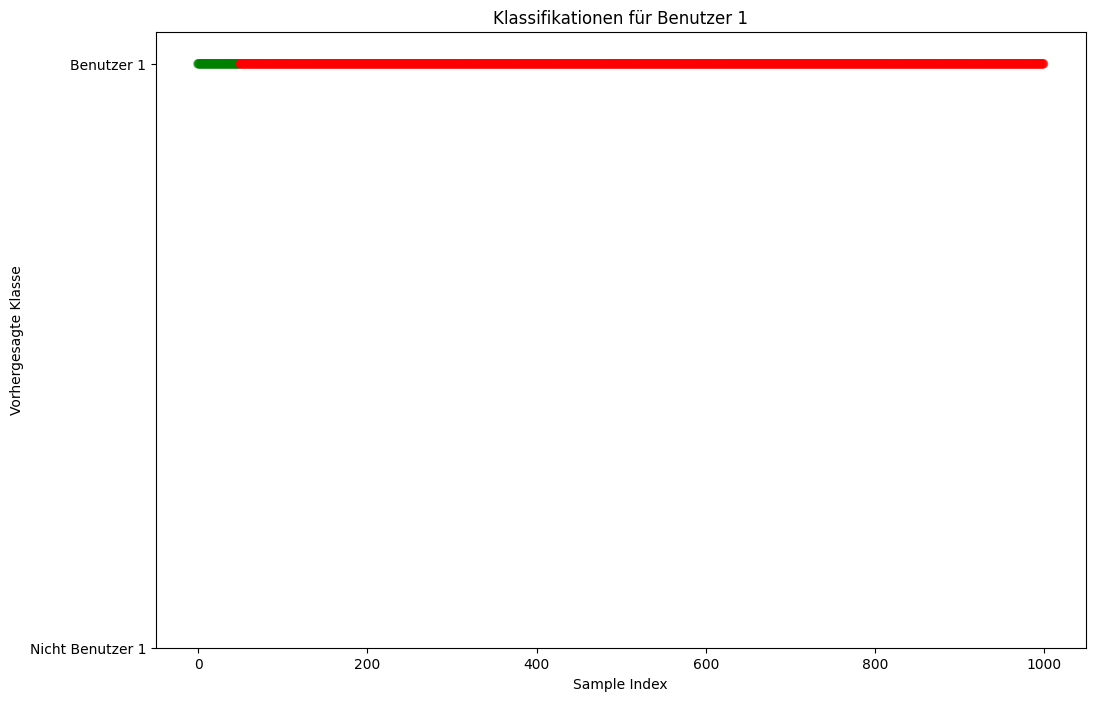

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Zufällige Samples von verschiedenen Benutzern auswählen
random_samples = []
random_labels = []
sample_users = []

for user_id in user_ids:
    user_df = user_dfs[user_id]
    samples = user_df.sample(n=50, random_state=42)  # 50 Samples pro Benutzer
    random_samples.extend(samples['sampleData'].tolist())
    sample_users.extend([user_id] * 50)
    if user_id == example_user_id:
        random_labels.extend([1] * 50)  # Label 1 für Benutzer 1
    else:
        random_labels.extend([0] * 50)  # Label 0 für andere Benutzer

# Bilddaten verarbeiten
X_random = np.array([process_image(sample) for sample in random_samples])
X_random = X_random / 255.0  # Normalisierung

# Vorhersagen mit dem Modell durchführen
y_pred = model.predict(X_random)
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_prob = y_pred[:, 1]  # Wahrscheinlichkeiten für Klasse 1 (Benutzer 1)

# Wahrscheinlichkeiten und Labels in einem DataFrame speichern
results_df = pd.DataFrame({
    'User': sample_users,
    'True Label': random_labels,
    'Predicted Probability': y_pred_prob,
    'Predicted Label': y_pred_classes
})

# Tabelle anzeigen
display(results_df)

# Sortieren nach vorhergesagter Wahrscheinlichkeit
sorted_results_df = results_df.sort_values(by='Predicted Probability', ascending=False)
display(sorted_results_df)

# Farben für True Positives, False Positives, True Negatives und False Negatives
def get_color(row):
    if row['True Label'] == 1 and row['Predicted Label'] == 1:
        return 'green'  # True Positive
    elif row['True Label'] == 0 and row['Predicted Label'] == 1:
        return 'red'    # False Positive
    elif row['True Label'] == 0 and row['Predicted Label'] == 0:
        return 'blue'   # True Negative
    else:
        return 'orange' # False Negative

results_df['Color'] = results_df.apply(get_color, axis=1)

# Graphen erstellen
plt.figure(figsize=(12, 8))
plt.scatter(range(len(results_df)), results_df['Predicted Label'], c=results_df['Color'], alpha=0.5)
plt.title('Klassifikationen für Benutzer 1')
plt.xlabel('Sample Index')
plt.ylabel('Vorhergesagte Klasse')
plt.yticks([0, 1], ['Nicht Benutzer 1', 'Benutzer 1'])
plt.show()

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Zufällige Samples von verschiedenen Benutzern auswählen
random_samples = []
random_labels = []
sample_users = []

# 2 Samples von Benutzer 1
user_df = user_dfs[example_user_id]
samples = user_df.sample(n=2, random_state=42)
random_samples.extend(samples['sampleData'].tolist())
sample_users.extend([example_user_id] * 2)
random_labels.extend([1] * 2)  # Label 1 für Benutzer 1

# 8 Samples von anderen Benutzern
other_user_ids = [user_id for user_id in user_ids if user_id != example_user_id]
for user_id in np.random.choice(other_user_ids, 8, replace=False):
    user_df = user_dfs[user_id]
    sample = user_df.sample(n=1, random_state=42)
    random_samples.extend(sample['sampleData'].tolist())
    sample_users.extend([user_id])
    random_labels.extend([0])  # Label 0 für andere Benutzer

# Bilddaten verarbeiten
X_random = np.array([process_image(sample) for sample in random_samples])
X_random = X_random / 255.0  # Normalisierung

# Vorhersagen mit dem Modell durchführen
y_pred = model.predict(X_random)
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_prob = y_pred[:, 1]  # Wahrscheinlichkeiten für Klasse 1 (Benutzer 1)

# Wahrscheinlichkeiten und Labels in einem DataFrame speichern
results_df = pd.DataFrame({
    'User': sample_users,
    'True Label': random_labels,
    'Predicted Label': y_pred_classes
})

# Ob die Vorhersage korrekt ist
results_df['Correct'] = results_df['True Label'] == results_df['Predicted Label']

# Klassifikationstyp hinzufügen
def get_classification(row):
    if row['True Label'] == 1 and row['Predicted Label'] == 1:
        return 'True Positive'
    elif row['True Label'] == 0 and row['Predicted Label'] == 1:
        return 'False Positive'
    elif row['True Label'] == 0 and row['Predicted Label'] == 0:
        return 'True Negative'
    else:
        return 'False Negative'

results_df['Classification'] = results_df.apply(get_classification, axis=1)

# Tabelle anzeigen
display(results_df)

# Sortieren nach vorhergesagter Wahrscheinlichkeit
sorted_results_df = results_df.sort_values(by='Predicted Probability', ascending=False)
display(sorted_results_df)

# Farben für True Positives, False Positives, True Negatives und False Negatives
def get_color(row):
    if row['True Label'] == 1 and row['Predicted Label'] == 1:
        return 'green'  # True Positive
    elif row['True Label'] == 0 and row['Predicted Label'] == 1:
        return 'red'    # False Positive
    elif row['True Label'] == 0 and row['Predicted Label'] == 0:
        return 'blue'   # True Negative
    else:
        return 'orange' # False Negative

results_df['Color'] = results_df.apply(get_color, axis=1)

# Graphen erstellen
plt.figure(figsize=(12, 8))
plt.scatter(range(len(results_df)), results_df['Predicted Label'], c=results_df['Color'], alpha=0.5)
plt.title('Klassifikationen für Benutzer 1')
plt.xlabel('Sample Index')
plt.ylabel('Vorhergesagte Klasse')
plt.yticks([0, 1], ['Nicht Benutzer 1', 'Benutzer 1'])
plt.show()

1/1 [==============================] - 0s 10ms/step


,User,True Label,Predicted Label,Correct,Classification
0,benutzername_1,1,1,True,True Positive
1,benutzername_1,1,1,True,True Positive
2,benutzername_4,0,1,False,False Positive
3,benutzername_8,0,1,False,False Positive
4,benutzername_13,0,1,False,False Positive
5,benutzername_9,0,1,False,False Positive
6,benutzername_6,0,1,False,False Positive
7,benutzername_17,0,1,False,False Positive
8,benutzername_18,0,1,False,False Positive
9,benutzername_15,0,1,False,False Positive


KeyError: 'Predicted Probability'